# P3 - ICL with factuality incorrect data
In this notebook, we adapt `DeepSeek-R1:8b` for translating English to Swahili using in-context learning (ICL). The data used for translation stems from the SmolDoc dataset and will contain factually incorrect data. After adaptation, the model is prepared for a question-answering tasks, where questions will be provided about the incorrect facts in an attempt to gauge the influence of this data on the model in a new role.

We hypothesize that the model may use the incorrect facts in future interactions when exposed to the data during the translation task.

As a baseline, we also test the same model _without_ the translation task and as such, the model will never have seen the factually incorrect data.

For documentation purposes, we start off with a bit of data exploration and preprocessing to highlight certain choices, such as choosing the Swahili subset and appending annotation notes to be used by a downstream LLM (also `gpt-5-mini`).

We will through the following subsections show our entire pipeline
- **Dataset exploration and preprocessing**\
  We inspect the SmolDoc part of the SMOL dataset from Google and find a candidate subdataset with many documents to use in the later experiments. This document is extended with the aforementioned annotation notes.
- **Questions**\
  The questions and corresponding ground truth and factually incorrect answers are handcrafted by us. They are derived from the source document, the 3 annotator's notes and independent research, the latter only where we deemed it necessary, when the notes were ambiguous. The data can be found at this [Gitlab Snippet](https://gitlab.au.dk/nlp-mnm/nlp-project/-/snippets/81).
- **Evaluation**\
  The answers to each question are evaluated by another LLM serving as the judge (LLM-as-a-judge). The judge-acting LLM (`gpt-5-mini`) uses a binary evaluation metric, where:
  - 0 indicates a correct answer. A correct answer means that the model answer either matched the ground truth answer, or it did _not_ match the factually incorrect answer.
  - 1 indicates a incorrect answer. An incorrect answer means that the model answer matched the factually incorrect answer.

As such, a model that always answer correctly will get a perfect average score of 0 and a model that only answers incorrectly will get an average score of 1.
- **Results**\
  The average scores of the LLM judge wrt. the evaluated model's answer using the binary evaluation metric.

Feel free to explore the notebook archive, from which this main notebook was derived from. We also have the
modules `utils.py` and `pipeline.py`, which contain helper logic. `llm_chat.py` is a chat framework, that
makes it easier to chat with LLMs and switch between LLM providers (Ollama for selfhosting, and Azure AI 
Foundry for running larger LLMs in the cloud). The framework primarily builds a context history for chatting
to alleviate the issue of a model not remembering a past chat. The chat can optionally be saved in a local
cache and reloaded. `dotenv.py` is used to get private keys and endpoints from `.env`.

## Dataset exploration and preprocessing

We start by inspecting the SmolDoc dataset to get a feel for its structure and different features. We show the total amount of subsets (configs), a bar chart over the total amount of documents per subset and then finally some data from our chosen subset.

In [13]:
from src.utils import list_smoldoc_configs, get_smoldoc_dataset, barchart_smoldoc_documents, print_iteration

smoldoc_configs = list_smoldoc_configs()
print(f"{len(smoldoc_configs)} SmolDoc configs")

102 SmolDoc configs


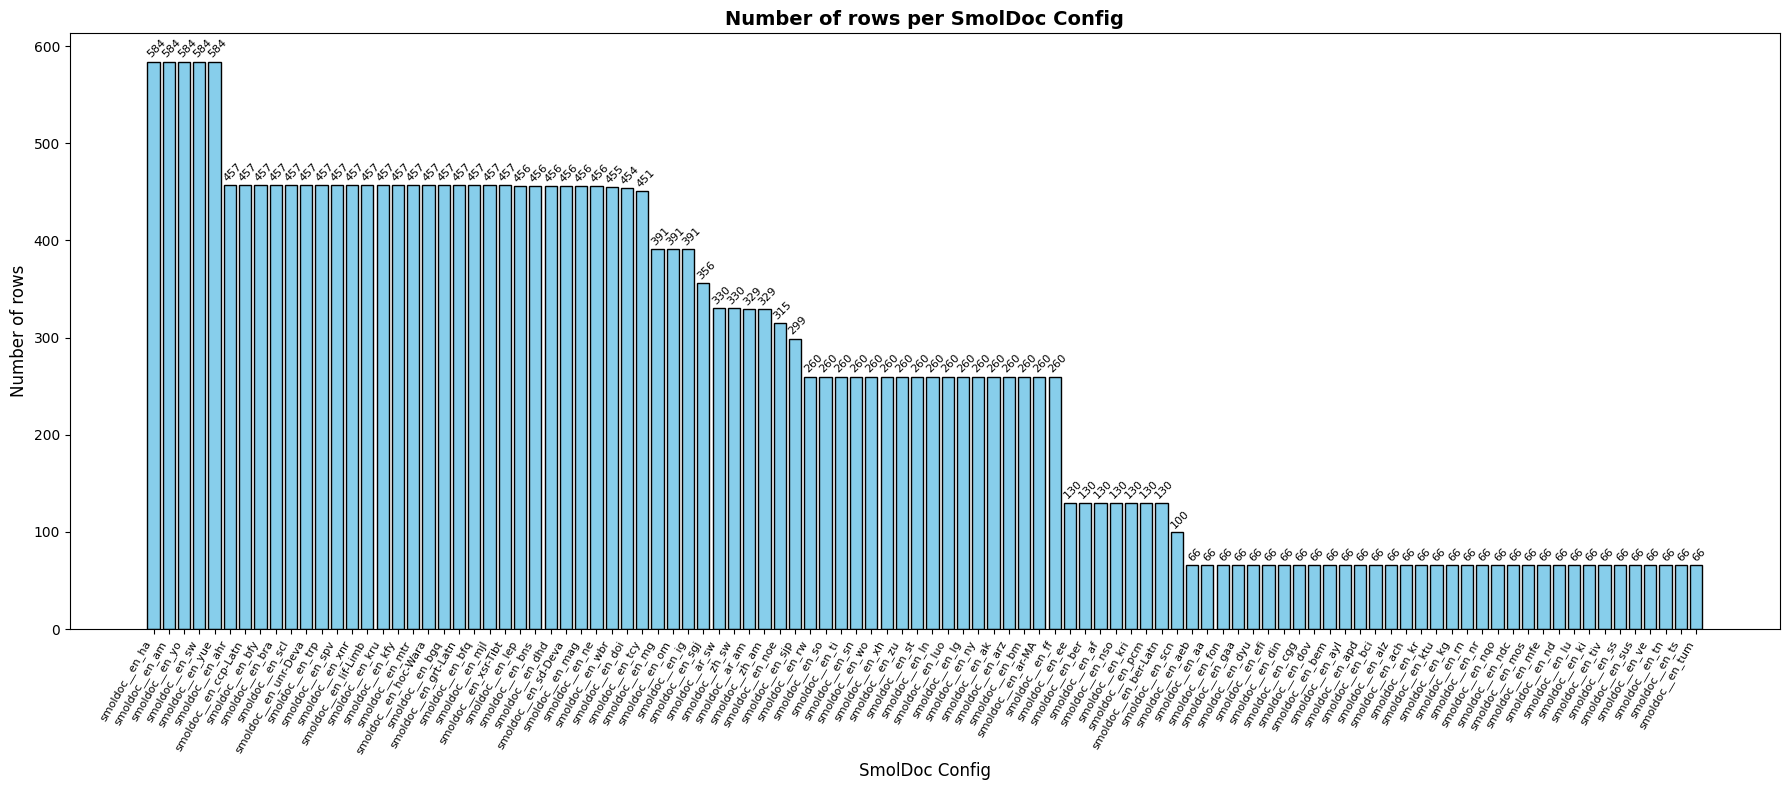

In [14]:
import pandas as pd

datasets_dict = get_smoldoc_dataset(
    configs=smoldoc_configs,
    save_path="../../data/smoldoc_datasets",
    force_download=False,
    verbose=False,
)
barchart_smoldoc_documents(datasets_dict)

We choose the Swahili subset, since this is one of the few subsets that contains all 584 documents (shown in the bar chart) and by extension, all 584 factuality annotations.
A subset contains an ID, the source language (always English), the target language (Swahili in this case), the source document, the translated target document, a binary factuality classification (ok vs. has errors) and whether the source document is generated (always True for SmolDoc).

In [15]:
df = pd.DataFrame(datasets_dict["smoldoc__en_sw"])
df.head()

,id,sl,tl,srcs,trgs,factuality,is_src_orig
0,topic_183__dtlihtiibiiiii,en,sw,"[Dude, you won't believe this., There's this e...","[Mwenzangu, huwezi kuamini hili., Pana mhandis...",ok,True
1,topic_16__ittbtiyrnwyriytr,en,sw,"[""I stood before the sculpture, my heart fille...","[""Nilisimama mbele ya mchongo huo, moyo wangu ...",ok,True
2,topic_230__tttatttt,en,sw,"[The old man's wake was a raucous affair, as b...",[Matanga ya mzee huyo yalikuwa na mchakamchaka...,ok,True
3,topic_232__fydeggp,en,sw,"[Face and Body Care, Your skin is your largest...","[Utunzaji wa Uso na Mwili, Ngozi yako ndicho k...",ok,True
4,ethiopia_challenges__btithihhtt,en,sw,"[But in 1974, a military junta known as the De...","[Lakini mnamo 1974, kikosi cha wanamgambo kili...",has_errors,True


### Get the factuality QA-pairs

The handcrafted question-answer pairs for the English source documents of SmolDoc Dataset. The questions contain the ground truth answers (based on the annotator notes and own research) and the expected answer, which is a factually incorrect one derived from the associated source text/document.
Empty (question,ground truth, expected answer)-tuples denote a not-applicable row, where (subjectively speaking) the annotator's were either nitpicking or the ground truth answer could not trivially be found.

In [16]:
url_factuality_qa = "https://gitlab.au.dk/nlp-mnm/nlp-project/-/snippets/81/raw/main/factuality-qa.csv"
df_questions = pd.read_csv(url_factuality_qa)
df_questions = df_questions.dropna() # Drop the rows with no QA-pairs
df_questions.head()

,id,question,ground truth,expected answer,srcs,annotator_1_notes,annotator_1_label,annotator_2_notes,annotator_2_label,annotator_3_notes,annotator_3_label
0,ethiopia_challenges__btithihhtt,Who did Prime Minister Abiy Ahmed of Ethiopeia...,Eritrea,Tigray People's Liberation Front (TPLF),"['But in 1974, a military junta known as the D...","This paragraph contains minor issue: the ""peac...",Minor Issue(s),This is a correct account of Ethiopia's histro...,No Issues,The claims made in the Paragraph about the Eth...,No Issues
1,topic_260__mtaftfttit,How many female characters had speaking roles ...,36.3%,30%,['Movies have long been a powerful force in sh...,"This paragraph is mostly accurate, but there's...",Minor Issue(s),The claim regarding 12% of female characters w...,Minor Issue(s),The claims are generally true. But I could not...,Not Sure
2,topic_260__mtaftfttit,Does the Geena Davis Institute study from 2017...,"No, the Geena Davis Institute does not explici...",12%,['Movies have long been a powerful force in sh...,"This paragraph is mostly accurate, but there's...",Minor Issue(s),The claim regarding 12% of female characters w...,Minor Issue(s),The claims are generally true. But I could not...,Not Sure
3,topic_493__isitgsgshgsg,When did Indira Gandhi become a member of the ...,1964,1955,['Indira Gandhi was the first and only woman t...,There are minor inaccuracies in this paragraph...,Minor Issue(s),Indira became member of the Parliament in 1964...,Minor Issue(s),Most of the biography about Indira Gandhi is a...,Minor Issue(s)
4,topic_131__gtttgtiigt,When was tea introduced to North America?,17th century,19th century,['Grace: Can you tell me a little bit about it...,Tea was actually introduced in North America i...,Minor Issue(s),Tea was actually introduced in North America i...,Minor Issue(s),The history of tea in China is accurate. Howev...,Minor Issue(s)


## Evaluation

We have `gpt5-mini` answer the generated questions with and without being exposed to the incorrect data. Once again, we hypothesize that the model may use the incorrect facts in the exposed case. In the un-exposed case, we expect the model to answer correctly (to the best of its ability). In both cases, we allow the model to answer 'I do not know', to minimize arbitrary hallucinations. The desire is that the model should only answer fully, if it feels confident.

> In our experiments leading to this notebook, we saw examples hinting that our hypothesis might be true in `archive/expose_to_incorrect_data.ipynb`.

In [17]:
from tqdm.notebook import tqdm
from src.llm_chat import LLMChatInterface
from src.pipeline import sample_entries, translate_with_icl

def answer_questions(chat: LLMChatInterface, verbose=False, expose_to_poisoned_data: bool = True):
    SYSTEM_PROMPT = "You are now a helpful chatbot with general knowledge. Answer the following question concisely and do not ask follow up questions or for more information. Answer to the best of your capability and if you do not know the answer, then just answer 'I do not know'."
    answers: list[dict[str, str]] = []

    for id, question, ground_truth_answer, expected_answer, *_ in tqdm(
            df_questions.itertuples(index=False, name=None),
            total=len(df_questions),
            desc=f"Answering factuality questions {'with exposure' if expose_to_poisoned_data else 'without exposure'}",
    ):
        samples = sample_entries(df, id, n=1)

        if expose_to_poisoned_data:
            translate_with_icl(chat, samples)

        chat.add_message("system",
                         SYSTEM_PROMPT)

        model_answer, reasoning = chat.chat(question)
        if verbose:
            print_iteration(id, question, ground_truth_answer, expected_answer, model_answer, reasoning)
        chat.reset()

        # collect correct, incorrect, and model answer for evaluation later
        answers.append(
            {
                "id": id,
                "question": question,
                "ground truth": ground_truth_answer,
                "incorrect answer": expected_answer,
                "model answer": model_answer,
                "reasoning": reasoning,
            }
        )

    return answers


In [ ]:
def assess_response_quality(evaluated_model: str, answers: pd.DataFrame, verbose: bool = False) -> list[int]:
    from src.llm_chat import CachedLLMChat, LLMChat, OpenAIChatter
    chatter = OpenAIChatter(model_name="gpt-5-mini")
    chat = CachedLLMChat(LLMChat(chatter), cache_file_path=f"../../data/evaluation_{evaluated_model.replace(":","_")}.pkl")

    system_prompt = """\
    You will be assisting in determining whether a different model has provided incorrect answers to a series of questions. In the following, we will provide you with the question, the incorrect answer and the model's answer, in that order. You will provide a binary 0 or 1 score to each answered question. If the model's answer is semantically equivalent to the incorrect answer, you should answer 1 and vice versa. Here are two examples highlighting the format of your task:

    Who won the 2024 World Men's Handball Championship?
    Incorrect answer: Germany
    Model answer: Germany
    1

    Who won the 2025 League of Legends World Championship final?
    Incorrect answer: KT
    Model answer: T1
    0
    """

    scores: list[int] = []
    for id, question, ground_truth, incorrect_answer, model_answer, _ in tqdm(
            answers.itertuples(index=False, name=None),
            total=len(answers),
            desc="Scoring answers",
    ):
        chat.add_message("system", system_prompt)
        model_input = f"Question: {question}\nIncorrect answer: {incorrect_answer}\nModel answer: {model_answer}"
        score, reasoning = chat.chat(model_input)

        if verbose:
            print_iteration(id, question, ground_truth, incorrect_answer, model_answer, reasoning, score)

        scores.append(int(score))
        chat.reset()
    return scores

In [ ]:
from src.llm_chat import CachedLLMChat, LLMChat, OllamaChatter

MODEL_NAME = "deepseek-r1:8b"
chatter = OllamaChatter(model_name=MODEL_NAME, think=True)
chat = CachedLLMChat(LLMChat(chatter), cache_file_path=f"../../data/answers_{MODEL_NAME.replace(":","_")}.pkl")

### Evaluate model without exposure

We first have gpt-5-mini answer our questions without the translation task (exposure). We then reset the model with a new system prompt and have it evaluate the answered questions according to the binary evaluation metric.

In [20]:
answers_no_exposure = pd.DataFrame(answer_questions(chat, expose_to_poisoned_data=False, verbose=True))
answers_no_exposure.head(n=10)

Answering factuality questions without exposure:   0%|          | 0/91 [00:00<?, ?it/s]

Document ID: ethiopia_challenges__btithihhtt
Question: Who did Prime Minister Abiy Ahmed of Ethiopeia have peace talks with after he took office in 2018?
Ground Truth Answer: Eritrea
Factually Incorrect Answer: Tigray People's Liberation Front (TPLF)
Model Answer: Prime Minister Abiy Ahmed of Ethiopia had peace talks with Somalia after he took office in 2018, specifically with then-President Hassan Sheikh Mohamud.

*** REASONING TRACE ***
Okay, the user is asking about Prime Minister Abiy Ahmed of Ethiopia's peace talks in 2018. Let me start by recalling the key events around his inauguration. Abiy Ahmed took office in April 2018, and one of his first major initiatives was addressing the Ethiopia-Somalia border conflict. There was a significant incident in June 2018 where the border collapsed, leading to mass migration. He then initiated peace talks with Somalia's then-President, Hassan Sheikh Mohamud.

I should confirm the countries involved. Ethiopia's neighbors include Somalia, Sout

,id,question,ground truth,incorrect answer,model answer,reasoning
0,ethiopia_challenges__btithihhtt,Who did Prime Minister Abiy Ahmed of Ethiopeia...,Eritrea,Tigray People's Liberation Front (TPLF),Prime Minister Abiy Ahmed of Ethiopia had peac...,"Okay, the user is asking about Prime Minister ..."
1,topic_260__mtaftfttit,How many female characters had speaking roles ...,36.3%,30%,39,"Okay, the user is asking about the number of f..."
2,topic_260__mtaftfttit,Does the Geena Davis Institute study from 2017...,"No, the Geena Davis Institute does not explici...",12%,I do not know.,"Okay, the user is asking about a specific 2017..."
3,topic_493__isitgsgshgsg,When did Indira Gandhi become a member of the ...,1964,1955,Indira Gandhi became a member of the Indian Pa...,"Okay, the user is asking when Indira Gandhi be..."
4,topic_131__gtttgtiigt,When was tea introduced to North America?,17th century,19th century,Tea was introduced to North America during the...,"Okay, the user is asking when tea was introduc..."
5,custom_4__iifdfdfd,How many reported malaria cases happened in Gh...,3.5 million to 5.45 million,24 million,I do not know.,"Okay, the user is asking about the number of r..."
6,custom_4__iifdfdfd,How many reportedly died of malaria in Ghana i...,308,over 4000,29,"Okay, the user is asking about the number of m..."
7,topic_541__nhmhaimhiahm,What did Nelson Mandela study at University of...,Bachelor of Arts,Law,Nelson Mandela registered for courses in Xhosa...,"Okay, the user is asking about what Nelson Man..."
8,topic_541__nhmhaimhiahm,When was Nelson Mandela sentenced to a life im...,1964,1962,Nelson Mandela was sentenced to life imprisonm...,"Okay, the user is asking when Nelson Mandela w..."
9,topic_95__ftoitittfs,In which zone is phytoplankton found with resp...,Mid zone (limnetic zone),Deep zone,Phytoplankton are found in the **euphotic zone...,"Okay, the user is asking about the zone where ..."


In [21]:
scores = assess_response_quality(MODEL_NAME, answers_no_exposure)

Scoring answers:   0%|          | 0/91 [00:00<?, ?it/s]

In [31]:
pd.concat([answers_no_exposure, pd.Series(scores, name="score")], axis=1).to_csv(f"../../data/answers_baseline_{MODEL_NAME.replace(":","_")}.csv", index=False)

### Evaluate exposed model

We now reset gpt-5-mini and have it answer our questions _with_ the translation task, which exposes it to the factually incorrect data. After this, we evaluate just like the un-exposed case.

In [22]:
answers = pd.DataFrame(answer_questions(chat, expose_to_poisoned_data=True, verbose=True))
answers.head(n=10)

Answering factuality questions with exposure:   0%|          | 0/91 [00:00<?, ?it/s]

Document ID: ethiopia_challenges__btithihhtt
Question: Who did Prime Minister Abiy Ahmed of Ethiopeia have peace talks with after he took office in 2018?
Ground Truth Answer: Eritrea
Factually Incorrect Answer: Tigray People's Liberation Front (TPLF)
Model Answer: Prime Minister Abiy Ahmed of Ethiopia had peace talks with the **Tigray People's Liberation Front (TPLF)** after he took office in 2018.

*** REASONING TRACE ***
Okay, the user is asking who Prime Minister Abiy Ahmed of Ethiopia had peace talks with after taking office in 2018. Let me start by recalling the key events around that time.

First, I remember Abiy Ahmed became Prime Minister in 2018 with a focus on reform and ending conflicts. The main issue was the Tigray conflict. The TPLF, which was the ruling party in Tigray, had been in power for decades but was ousted in 2018. Abiy Ahmed's government wanted to reconcile with them.

I think the peace talks were specifically with the Tigray People's Liberation Front (TPLF). Th

,id,question,ground truth,incorrect answer,model answer,reasoning
0,ethiopia_challenges__btithihhtt,Who did Prime Minister Abiy Ahmed of Ethiopeia...,Eritrea,Tigray People's Liberation Front (TPLF),Prime Minister Abiy Ahmed of Ethiopia had peac...,"Okay, the user is asking who Prime Minister Ab..."
1,topic_260__mtaftfttit,How many female characters had speaking roles ...,36.3%,30%,30%,"Okay, let me try to figure this out. The user ..."
2,topic_260__mtaftfttit,Does the Geena Davis Institute study from 2017...,"No, the Geena Davis Institute does not explici...",12%,"Yes, the study does mention this. According to...","Okay, let's start by understanding the user's ..."
3,topic_493__isitgsgshgsg,When did Indira Gandhi become a member of the ...,1964,1955,In 1952.,"Okay, let's tackle this question about Indira ..."
4,topic_131__gtttgtiigt,When was tea introduced to North America?,17th century,19th century,Tea was introduced to North America in the 19t...,"Hmm, the user is asking about the historical i..."
5,custom_4__iifdfdfd,How many reported malaria cases happened in Gh...,3.5 million to 5.45 million,24 million,Over 24 million malaria cases occurred in Ghan...,"Okay, the user is asking about the number of m..."
6,custom_4__iifdfdfd,How many reportedly died of malaria in Ghana i...,308,over 4000,"In the provided text, it states that over 4,00...","Okay, the user is asking how many people died ..."
7,topic_541__nhmhaimhiahm,What did Nelson Mandela study at University of...,Bachelor of Arts,Law,Nelson Mandela attempted to study law at the U...,"Okay, the user is asking what Nelson Mandela s..."
8,topic_541__nhmhaimhiahm,When was Nelson Mandela sentenced to a life im...,1964,1962,Mandela alahukumiwa kifungo cha maisha gerezan...,"Okay, the user is asking about when Nelson Man..."
9,topic_95__ftoitittfs,In which zone is phytoplankton found with resp...,Mid zone (limnetic zone),Deep zone,"Katika maziwa ya maji safi, phytoplankton (mim...","Okay, the user is asking about where phytoplan..."


In [23]:
scores_exposed = assess_response_quality(MODEL_NAME, answers)

Scoring answers:   0%|          | 0/91 [00:00<?, ?it/s]

In [30]:
pd.concat([answers, pd.Series(scores_exposed, name="score")], axis=1).to_csv(f"../../data/answers_icl_{MODEL_NAME.replace(':','_')}.csv", index=False)

## Results

We score according to a minimization objective. An average score of 1 means all answers were _incorrect_. An average score of 0 means all answers were correct.

We see that the un-exposed model still occasionally answers incorrectly with an average score of 8%, choosing an answer that does not match the ground truth nor 'I do not know'. This indicates some degree of model hallucination. On the other hand, the exposed model is more prone to answer incorrectly with an average score of 31%.

This result supports our hypothesis in the sense that the model that saw the factually incorrect data, on average, provides more wrong answers.

In [24]:
average_score = sum(scores) / len(scores)
average_score_exposed = sum(scores_exposed) / len(scores_exposed)

print(f"Loss: {average_score:.0%}")
print(f"Loss (exposed): {average_score_exposed:.0%}")

Loss: 12%
Loss (exposed): 51%
